In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
from torch.optim.lr_scheduler import MultiStepLR
import numpy as np
import copy
from torch.func import vmap, grad
import os
import glob

# ── multi-GPU setup ──────────────────────────────────────────────────────────
os.makedirs('./checkpoints', exist_ok=True)
os.makedirs('./data', exist_ok=True)

device       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_gpus     = torch.cuda.device_count()          # 0, 1 or 2
use_ddp      = num_gpus > 1                        # True when 2 GPUs are present
torch.manual_seed(42)
print(f'Device: {device}  |  GPUs found: {num_gpus}  |  DataParallel: {use_ddp}')


Device: cuda  |  GPUs found: 2  |  DataParallel: True


In [2]:
# ── reproducible label-noise ──────────────────────────────────────────────────
# We persist the flip indices so that a resumed run uses EXACTLY the same noise.
FLIP_IDX_PATH = './checkpoints/flip_idx.npy'

transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True,  download=True, transform=transform_train)
train_nonaug  = torchvision.datasets.CIFAR10(
    root='./data', train=True,  download=True, transform=transform_test)
test_dataset  = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform_test)

original_targets = copy.deepcopy(train_dataset.targets)

if os.path.exists(FLIP_IDX_PATH):
    flip_idx = np.load(FLIP_IDX_PATH)
    print(f'Loaded existing flip indices from {FLIP_IDX_PATH}')
else:
    num_flip = int(0.1 * len(train_dataset))
    flip_idx = np.random.choice(len(train_dataset), num_flip, replace=False)
    np.save(FLIP_IDX_PATH, flip_idx)
    print(f'Generated and saved {num_flip} flip indices')

for i in flip_idx:
    train_dataset.targets[i] = (train_dataset.targets[i] + 1) % 10

mislabelled_set = set(flip_idx.tolist())

# pin_memory only makes sense with CUDA
pin = device.type == 'cuda'
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=256 * max(1, num_gpus),
    shuffle=True, num_workers=4, pin_memory=pin, persistent_workers=True)

print(f'Effective batch size: {256 * max(1, num_gpus)}')


Loaded existing flip indices from ./checkpoints/flip_idx.npy
Effective batch size: 512


In [3]:
# ── helpers ───────────────────────────────────────────────────────────────────
CKPT_DIR          = './checkpoints'
TRAINING_CKPT     = os.path.join(CKPT_DIR, 'training_state.pt')   # rolling resume file
CHECKPOINT_EPOCHS = list(range(30, 271, 30))                        # 30,60,...,270


def epoch_ckpt_path(epoch: int) -> str:
    """Path for a TracIn-style per-epoch checkpoint."""
    return os.path.join(CKPT_DIR, f'epoch_{epoch:04d}.pt')


def load_tracin_checkpoints() -> list:
    """Return all already-saved TracIn checkpoints, sorted by epoch."""
    ckpts = []
    for ep in CHECKPOINT_EPOCHS:
        p = epoch_ckpt_path(ep)
        if os.path.exists(p):
            ckpts.append(torch.load(p, map_location='cpu'))
    return ckpts


def build_model() -> nn.Module:
    m = models.resnet18(num_classes=10)
    if use_ddp:
        m = nn.DataParallel(m)          # transparent multi-GPU
    return m.to(device)


def fc_module(m: nn.Module) -> nn.Linear:
    """Return the final FC layer regardless of DataParallel wrapping."""
    return m.module.fc if isinstance(m, nn.DataParallel) else m.fc


def forward_features(m: nn.Module, x: torch.Tensor) -> torch.Tensor:
    """ResNet backbone up to (but not including) the FC layer."""
    base = m.module if isinstance(m, nn.DataParallel) else m
    x = base.maxpool(base.relu(base.bn1(base.conv1(x))))
    x = base.layer4(base.layer3(base.layer2(base.layer1(x))))
    x = base.avgpool(x)
    return torch.flatten(x, 1)


In [4]:
# ── training with crash-safe resumption ──────────────────────────────────────
criterion = nn.CrossEntropyLoss()

# ── decide where to resume ───────────────────────────────────────────────────
start_epoch = 1
model       = build_model()
optimizer   = torch.optim.SGD(
    model.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
scheduler   = MultiStepLR(optimizer, milestones=[90, 180, 240], gamma=0.1)

if os.path.exists(TRAINING_CKPT):
    state = torch.load(TRAINING_CKPT, map_location=device)
    model.load_state_dict(state['model'])
    optimizer.load_state_dict(state['optimizer'])
    scheduler.load_state_dict(state['scheduler'])
    start_epoch = state['epoch'] + 1          # next epoch to run
    print(f'▶  Resuming training from epoch {start_epoch}')
else:
    print('▶  Starting training from scratch')

# ── training loop ────────────────────────────────────────────────────────────
for epoch in range(start_epoch, 271):
    model.train()
    running_loss = 0.0
    for data, target in train_loader:
        data, target = data.to(device, non_blocking=pin), target.to(device, non_blocking=pin)
        optimizer.zero_grad()
        loss = criterion(model(data), target)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    scheduler.step()
    avg_loss = running_loss / len(train_loader)

    # ── always save rolling resume state (overwrites previous) ──────────────
    torch.save({
        'epoch'    : epoch,
        'model'    : model.state_dict(),
        'optimizer': optimizer.state_dict(),
        'scheduler': scheduler.state_dict(),
    }, TRAINING_CKPT)

    # ── save TracIn checkpoint at designated epochs ──────────────────────────
    if epoch in CHECKPOINT_EPOCHS:
        torch.save({
            'epoch'           : epoch,
            'model_state_dict': {k: v.cpu() for k, v in model.state_dict().items()},
            'learning_rate'   : optimizer.param_groups[0]['lr'],
        }, epoch_ckpt_path(epoch))
        print(f'  ✔  TracIn checkpoint saved  (epoch {epoch}, lr={optimizer.param_groups[0]["lr"]:.5f}, loss={avg_loss:.4f})')
    elif epoch % 10 == 0:
        print(f'  epoch {epoch:3d}  loss={avg_loss:.4f}')

print('Training complete.')

# load all TracIn checkpoints into memory for later cells
checkpoints = load_tracin_checkpoints()
print(f'TracIn checkpoints available: {[c["epoch"] for c in checkpoints]}')


▶  Resuming training from epoch 271
Training complete.
TracIn checkpoints available: [30, 60, 90, 120, 150, 180, 210, 240, 270]


In [5]:
# ── influence functions ───────────────────────────────────────────────────────

def compute_last_layer_gradient(model, example, label, criterion, device):
    """
    Computes the loss gradient w.r.t. the final FC layer parameters.

    Args:
        model     : ResNet model (possibly DataParallel-wrapped).
        example   : Single input tensor  (C, H, W).
        label     : Target label tensor  (scalar or 1-D).
        criterion : Loss function.
        device    : Execution device.

    Returns:
        1-D CPU tensor  [weight_grad | bias_grad].
    """
    fc = fc_module(model)
    model.zero_grad()
    example = example.unsqueeze(0).to(device)
    label   = label.reshape(1).to(device)
    loss    = criterion(model(example), label)
    loss.backward()

    g_w = fc.weight.grad.view(-1)
    g_b = fc.bias.grad.view(-1) if fc.bias is not None else torch.tensor([], device=device)
    return torch.cat([g_w, g_b]).detach().cpu()


def compute_all_self_influences_functorch(
        train_dataset, checkpoints, criterion, device, batch_size=256):
    """
    TracInCP self-influence scores via per-sample gradients (vmap).

    Args:
        train_dataset : Un-augmented training dataset.
        checkpoints   : List of TracIn checkpoint dicts.
        criterion     : Loss function.
        device        : Execution device.
        batch_size    : Feature-extraction batch size.

    Returns:
        (self_influences np.ndarray, indices list)
    """
    num_examples  = len(train_dataset)
    self_influences = np.zeros(num_examples)
    dataloader    = torch.utils.data.DataLoader(
        train_dataset, batch_size=batch_size, shuffle=False,
        num_workers=4, pin_memory=pin, persistent_workers=True)

    for ckpt_idx, checkpoint in enumerate(checkpoints):
        # build a plain (non-DataParallel) model for functional transforms
        base_model = models.resnet18(num_classes=10).to(device)
        # strip DataParallel prefix if present
        raw_state  = {k.replace('module.', ''): v
                      for k, v in checkpoint['model_state_dict'].items()}
        base_model.load_state_dict(raw_state)
        base_model.eval()
        lr = checkpoint['learning_rate']

        params  = {k: v.detach() for k, v in base_model.fc.named_parameters()}
        buffers = {}

        def compute_loss_fc_only(params, buffers, input_features, target):
            logits = torch.nn.functional.linear(
                input_features, params['weight'], params.get('bias'))
            return criterion(logits.unsqueeze(0), target.unsqueeze(0))

        ft_compute_grad        = grad(compute_loss_fc_only)
        ft_compute_sample_grad = vmap(ft_compute_grad, in_dims=(None, None, 0, 0))

        current_idx = 0
        for batch_examples, batch_labels in dataloader:
            batch_examples = batch_examples.to(device, non_blocking=pin)
            batch_labels   = batch_labels.to(device, non_blocking=pin)

            with torch.no_grad():
                features = forward_features(base_model, batch_examples)

            per_sample_grads = ft_compute_sample_grad(
                params, buffers, features, batch_labels)

            # vectorised score update (avoids Python loop over batch)
            parts = [per_sample_grads['weight'].flatten(1)]
            if 'bias' in per_sample_grads:
                parts.append(per_sample_grads['bias'].flatten(1))
            g_mat = torch.cat(parts, dim=1)          # (B, D)
            scores_batch = lr * (g_mat ** 2).sum(dim=1).cpu().numpy()
            bs = len(batch_labels)
            self_influences[current_idx: current_idx + bs] += scores_batch
            current_idx += bs

        print(f'  checkpoint {ckpt_idx+1}/{len(checkpoints)} '
              f'(epoch {checkpoint["epoch"]}) done')

    return self_influences, list(range(num_examples))


def find_proponents_opponents(
        test_example, test_label, train_dataset,
        checkpoints, criterion, device, top_k=5):
    """
    Most positively / negatively influential training examples for a test point.

    Args:
        test_example  : Input tensor  (C, H, W).
        test_label    : Ground-truth label tensor.
        train_dataset : Full un-augmented training dataset.
        checkpoints   : List of TracIn checkpoint dicts.
        criterion     : Loss function.
        device        : Execution device.
        top_k         : Number of proponents / opponents to return.

    Returns:
        (proponents list, opponents list)  each element is (score, idx).
    """
    num_examples = len(train_dataset)
    scores       = np.zeros(num_examples)

    for checkpoint in checkpoints:
        base_model = models.resnet18(num_classes=10).to(device)
        raw_state  = {k.replace('module.', ''): v
                      for k, v in checkpoint['model_state_dict'].items()}
        base_model.load_state_dict(raw_state)
        base_model.eval()
        lr = checkpoint['learning_rate']

        grad_test = compute_last_layer_gradient(
            base_model, test_example, test_label, criterion, device)

        for idx in range(num_examples):
            train_ex, train_label_int = train_dataset[idx]
            train_label = torch.tensor([train_label_int])
            grad_train  = compute_last_layer_gradient(
                base_model, train_ex, train_label, criterion, device)
            scores[idx] += lr * torch.dot(grad_train, grad_test).item()

    indexed_scores = sorted(enumerate(scores), key=lambda x: x[1], reverse=True)
    indexed_scores = [(s, i) for i, s in indexed_scores]
    return indexed_scores[:top_k], indexed_scores[-top_k:]


In [6]:
# ── self-influence computation (resumable) ────────────────────────────────────
SI_CACHE = './checkpoints/self_influences.npy'

if os.path.exists(SI_CACHE):
    self_influences = np.load(SI_CACHE)
    indices         = list(range(len(self_influences)))
    print(f'Loaded cached self-influence scores from {SI_CACHE}')
else:
    # make sure we have all checkpoints in memory
    checkpoints = load_tracin_checkpoints()
    self_influences, indices = compute_all_self_influences_functorch(
        train_nonaug, checkpoints, criterion, device, batch_size=256)
    np.save(SI_CACHE, self_influences)
    print(f'Self-influence scores saved to {SI_CACHE}')

sorted_idx = np.argsort(self_influences)[::-1]


Loaded cached self-influence scores from ./checkpoints/self_influences.npy


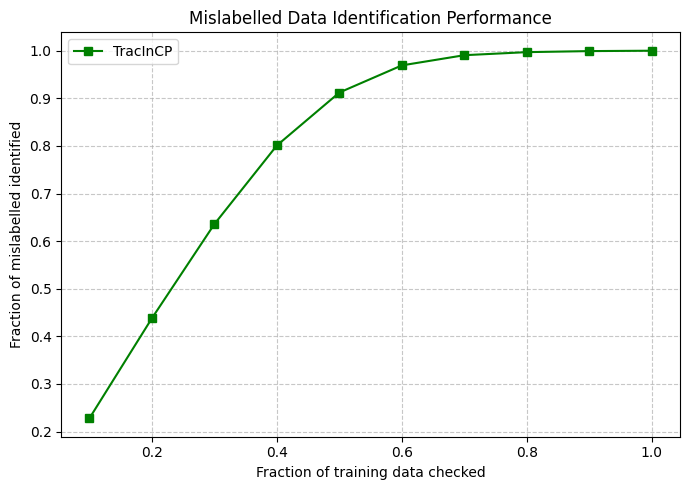

In [7]:
import matplotlib.pyplot as plt

# ── Plot 1: fraction of mislabelled examples identified ───────────────────────
total_mislabelled   = len(mislabelled_set)
fractions_to_check  = np.arange(0.1, 1.1, 0.1)
fraction_identified = []

for frac in fractions_to_check:
    k              = int(frac * len(train_dataset))
    top_k_indices  = sorted_idx[:k]
    found          = sum(1 for idx in top_k_indices if idx in mislabelled_set)
    fraction_identified.append(found / total_mislabelled)

plt.figure(figsize=(7, 5))
plt.plot(fractions_to_check, fraction_identified,
         marker='s', color='green', label='TracInCP')
plt.xlabel('Fraction of training data checked')
plt.ylabel('Fraction of mislabelled identified')
plt.title('Mislabelled Data Identification Performance')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


Resuming retrain experiments. Completed fractions: [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
  frac=0.0 already done — skipping
  frac=0.1 already done — skipping
  frac=0.2 already done — skipping
  frac=0.3 already done — skipping
  frac=0.4 already done — skipping
  frac=0.5 already done — skipping


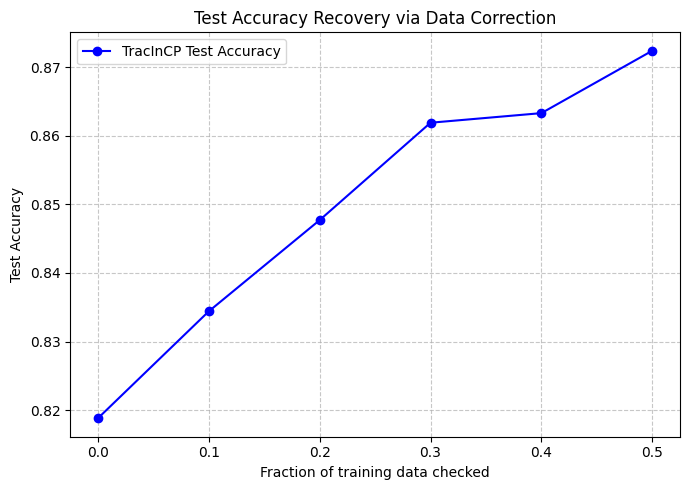

In [9]:
# ── Plot 2: test-accuracy recovery after data correction ─────────────────────
RETRAIN_RESULTS_CACHE = './checkpoints/retrain_accuracies.npy'
RETRAIN_STATE_CACHE   = './checkpoints/retrain_state.npy'   # tracks completed fractions

fractions_to_fix = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
test_loader      = torch.utils.data.DataLoader(
    test_dataset, batch_size=256, shuffle=False,
    num_workers=2, pin_memory=pin)

# load any previously completed retrain results
if os.path.exists(RETRAIN_RESULTS_CACHE) and os.path.exists(RETRAIN_STATE_CACHE):
    test_accuracies   = np.load(RETRAIN_RESULTS_CACHE).tolist()
    completed_fracs   = np.load(RETRAIN_STATE_CACHE).tolist()
    print(f'Resuming retrain experiments. Completed fractions: {completed_fracs}')
else:
    test_accuracies = []
    completed_fracs = []

for frac in fractions_to_fix:
    if frac in completed_fracs:
        print(f'  frac={frac:.1f} already done — skipping')
        continue

    print(f'  Retraining with frac={frac:.1f} ...')
    fixed_dataset = copy.deepcopy(train_dataset)
    k             = int(frac * len(train_dataset))
    for idx in sorted_idx[:k]:
        if idx in mislabelled_set:
            fixed_dataset.targets[idx] = original_targets[idx]

    fixed_loader = torch.utils.data.DataLoader(
        fixed_dataset, batch_size=256 * max(1, num_gpus),
        shuffle=True, num_workers=4, pin_memory=pin, persistent_workers=True)

    retrain_model     = build_model()
    retrain_optimizer = torch.optim.SGD(
        retrain_model.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
    retrain_scheduler = MultiStepLR(
        retrain_optimizer, milestones=[90, 180, 240], gamma=0.1)

    # ── per-fraction rolling resume ──────────────────────────────────────────
    frac_ckpt_path  = os.path.join(CKPT_DIR, f'retrain_frac{frac:.1f}_state.pt')
    retrain_start   = 0
    if os.path.exists(frac_ckpt_path):
        rt_state = torch.load(frac_ckpt_path, map_location=device)
        retrain_model.load_state_dict(rt_state['model'])
        retrain_optimizer.load_state_dict(rt_state['optimizer'])
        retrain_scheduler.load_state_dict(rt_state['scheduler'])
        retrain_start = rt_state['epoch'] + 1
        print(f'    resumed retrain (frac={frac:.1f}) from epoch {retrain_start}')

    retrain_model.train()
    for epoch in range(retrain_start, 270):
        for data, target in fixed_loader:
            data, target = (data.to(device, non_blocking=pin),
                            target.to(device, non_blocking=pin))
            retrain_optimizer.zero_grad()
            loss = criterion(retrain_model(data), target)
            loss.backward()
            retrain_optimizer.step()
        retrain_scheduler.step()

        # save rolling retrain resume state
        torch.save({
            'epoch'    : epoch,
            'model'    : retrain_model.state_dict(),
            'optimizer': retrain_optimizer.state_dict(),
            'scheduler': retrain_scheduler.state_dict(),
        }, frac_ckpt_path)

    retrain_model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            _, predicted = torch.max(retrain_model(data), 1)
            total   += target.size(0)
            correct += (predicted == target).sum().item()

    acc = correct / total
    test_accuracies.append(acc)
    completed_fracs.append(frac)

    # persist results after every fraction so a crash loses nothing
    np.save(RETRAIN_RESULTS_CACHE, np.array(test_accuracies))
    np.save(RETRAIN_STATE_CACHE,   np.array(completed_fracs))
    print(f'    frac={frac:.1f}  test_acc={acc:.4f}  (saved)')

    # clean up the per-fraction rolling file (run is complete)
    if os.path.exists(frac_ckpt_path):
        os.remove(frac_ckpt_path)

# sort by fraction before plotting (in case of partial earlier runs)
pairs           = sorted(zip(completed_fracs, test_accuracies))
sorted_fracs    = [p[0] for p in pairs]
sorted_accs     = [p[1] for p in pairs]

plt.figure(figsize=(7, 5))
plt.plot(sorted_fracs, sorted_accs,
         marker='o', color='blue', label='TracInCP Test Accuracy')
plt.xlabel('Fraction of training data checked')
plt.ylabel('Test Accuracy')
plt.title('Test Accuracy Recovery via Data Correction')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
